#**Sector-Specific Government Policy Tracker**

OVERVIEW: This project demonstrates a basic ETL pipeline and analysis of US agency policy documents that may affect the tech industry. Sequentially, it:
1. Pulls all Federal Register documents instances within the past 6 months
2. Basic cleaning/munging
3. Fetching the actual documents themselves.
4. Transformer based model comparison to a given topic, industry, sector, etc.

Step 1. Data Pull

In [36]:
import requests
import pandas as pd
import datetime
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup
import time
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from tqdm.auto import tqdm

In [37]:
#Preemptively
pd.set_option('display.max_columns', None)

In [38]:
#Calculate the date for six months ago
six_months_ago = (datetime.date.today() - datetime.timedelta(days=180)).isoformat()

#define API endpoint - This is quite long because the basic request doesn't pull all fields, and for exploratory reasons I'd like to take a look at them all.

#Here, we filter out notices, since these are usually junk
url = 'https://www.federalregister.gov/api/v1/documents.json?fields[]=abstract&fields[]=action&fields[]=agencies&fields[]=agency_names&fields[]=cfr_topics&fields[]=citation&fields[]=comments_close_on&fields[]=correction_of&fields[]=dates&fields[]=document_number&fields[]=effective_on&fields[]=end_page&fields[]=excerpts&fields[]=executive_order_notes&fields[]=executive_order_number&fields[]=explanation&fields[]=full_text_xml_url&fields[]=president&fields[]=presidential_document_number&fields[]=proclamation_number&fields[]=public_inspection_pdf_url&fields[]=publication_date&fields[]=raw_text_url&fields[]=significant&fields[]=signing_date&fields[]=start_page&fields[]=subtype&fields[]=title&fields[]=toc_doc&fields[]=toc_subject&fields[]=topics&fields[]=type&conditions[type][]=RULE&conditions[type][]=PRORULE&conditions[type][]=PRESDOCU&fields[]=volume&per_page='

params = {
    'per_page': 1000,
    'conditions[publication_date][gte]': six_months_ago
}

#Fetch
response = requests.get(url, params=params)
response.raise_for_status()
data = response.json()

data['results'][0] #Let's take a look at a response

{'abstract': 'This action proposes to establish Class E airspace extending upward from 700 feet above the surface at Tishomingo Airport, Belmont, MS. Controlled airspace is necessary for the safety and management of instrument flight rules (IFR) operations at this airport.',
 'action': 'Notice of proposed rulemaking (NPRM).',
 'agencies': [{'raw_name': 'DEPARTMENT OF TRANSPORTATION',
   'name': 'Transportation Department',
   'id': 492,
   'url': 'https://www.federalregister.gov/agencies/transportation-department',
   'json_url': 'https://www.federalregister.gov/api/v1/agencies/492',
   'parent_id': None,
   'slug': 'transportation-department'},
  {'raw_name': 'Federal Aviation Administration',
   'name': 'Federal Aviation Administration',
   'id': 159,
   'url': 'https://www.federalregister.gov/agencies/federal-aviation-administration',
   'json_url': 'https://www.federalregister.gov/api/v1/agencies/159',
   'parent_id': 492,
   'slug': 'federal-aviation-administration'}],
 'agency_na

TODO: Add pagination later

Now let's flatten the data for readability's sake

In [39]:
#Flatten
df = pd.json_normalize(data['results'])

print(f"Retrieved {len(df)} documents.")
display(df.head())

Retrieved 1000 documents.


,abstract,action,agencies,agency_names,cfr_topics,citation,comments_close_on,correction_of,dates,document_number,effective_on,end_page,excerpts,executive_order_notes,executive_order_number,full_text_xml_url,presidential_document_number,proclamation_number,public_inspection_pdf_url,publication_date,raw_text_url,significant,signing_date,start_page,subtype,title,toc_doc,toc_subject,topics,type,volume,president.identifier,president.name
0,This action proposes to establish Class E airs...,Notice of proposed rulemaking (NPRM).,"[{'raw_name': 'DEPARTMENT OF TRANSPORTATION', ...","[Transportation Department, Federal Aviation A...","[{'cfr_part': '71', 'topics': ['Airspace', 'In...",91 FR 37059,2026-08-06,NaN,Comments must be received on or before August ...,2026-12535,NaN,37061,This action proposes to establish Class E airs...,NaN,NaN,https://www.federalregister.gov/documents/full...,NaN,NaN,NaN,2026-06-22,https://www.federalregister.gov/documents/full...,False,NaN,37059,NaN,"Establishment of Class E Airspace; Belmont, MS","Belmont, MS",Airspace Designations and Reporting Points,"[Airspace, Incorporation by reference, Navigat...",Proposed Rule,91,donald-trump,Donald Trump
1,"In this document, the Federal Communications C...",Direct final rule.,[{'raw_name': 'FEDERAL COMMUNICATIONS COMMISSI...,[Federal Communications Commission],[],91 FR 37043,2026-07-13,NaN,"These rules are effective August 21, 2026 with...",2026-12510,2026-08-21,37047,"In this document, the Federal Communications C...",NaN,NaN,https://www.federalregister.gov/documents/full...,NaN,NaN,NaN,2026-06-22,https://www.federalregister.gov/documents/full...,None,NaN,37043,NaN,Deletion of Obsolete Regulations,Deletion of Obsolete Regulations,NaN,[],Rule,91,donald-trump,Donald Trump
2,This action establishes Class E airspace at La...,Final rule.,"[{'raw_name': 'DEPARTMENT OF TRANSPORTATION', ...","[Transportation Department, Federal Aviation A...","[{'cfr_part': '71', 'topics': ['Airspace', 'In...",91 FR 36975,NaN,NaN,"Effective 0901 UTC, October 29, 2026. The Dire...",2026-12496,2026-10-29,36976,This action establishes Class E airspace at La...,NaN,NaN,https://www.federalregister.gov/documents/full...,NaN,NaN,NaN,2026-06-22,https://www.federalregister.gov/documents/full...,False,NaN,36975,NaN,"Establishment of Class E Airspace; Rosenberg, TX","Rosenberg, TX",Airspace Designations and Reporting Points,"[Airspace, Incorporation by reference, Navigat...",Rule,91,donald-trump,Donald Trump
3,This action proposes to amend domestic Very Hi...,Notice of proposed rulemaking (NPRM).,"[{'raw_name': 'DEPARTMENT OF TRANSPORTATION', ...","[Transportation Department, Federal Aviation A...","[{'cfr_part': '71', 'topics': ['Airspace', 'In...",91 FR 37062,2026-08-06,NaN,Comments must be received on or before August ...,2026-12491,NaN,37065,This action proposes to amend domestic Very Hi...,NaN,NaN,https://www.federalregister.gov/documents/full...,NaN,NaN,NaN,2026-06-22,https://www.federalregister.gov/documents/full...,False,NaN,37062,NaN,Amendment of Domestic Very High Frequency Omni...,Eastern United States,Airspace Designations and Reporting Points,"[Airspace, Incorporation by reference, Navigat...",Proposed Rule,91,donald-trump,Donald Trump
4,The Coast Guard is establishing a temporary sa...,Temporary final rule.,[{'raw_name': 'DEPARTMENT OF HOMELAND SECURITY...,"[Homeland Security Department, Coast Guard]","[{'cfr_part': '165', 'topics': ['Harbors', 'Ma...",91 FR 36992,NaN,NaN,This rule is effective from 9 p.m. to 9:30 p.m...,2026-12490,2026-07-04,36993,The Coast Guard is establishing a temporary sa...,NaN,NaN,https://www.federalregister.gov/documents/full...,NaN,NaN,NaN,2026-06-22,https://www.federalregister.gov/documents/full...,False,NaN,36992,NaN,"Safety Zone; Delaware River, Philadelphia, PA","Delaware River, Philadelphia, PA",Safety Zone,"[Harbors, Marine safety, Navigation (water), R...",Rule,91,donald-trump,Donald Trump


It appears that the endpoint doesn't immediately expose the entire text of a document itself, which we should probably have for overall data completeness purposes.

Let's grab that before we begin. it appears it can be fetched from the full_text_xml_url endpoint.

It appears that the columns ***document number*** and ***date*** are required for endpoint specification to extract individual full text documents. Let's write a function to do this.
- However, per the endpoint, publication_date must be in YYYY/MM/DD format. Let's create that now.

In [40]:
df['publication_date'] = pd.to_datetime(df['publication_date']).dt.strftime('%Y/%m/%d')
df['publication_date'][0]

'2026/06/22'

In [41]:
#Function to retrieve full text
def get_full_text(df, doc_num, date):
  full_text_url = f'https://www.federalregister.gov/documents/full_text/xml/{date}/{doc_num}.xml'
  response = requests.get(full_text_url)
  return response.text

#Test
get_full_text(df, df['document_number'][0], df['publication_date'][0])

'<PRORULE>\n            <PREAMB>\n                <AGENCY TYPE="S">DEPARTMENT OF TRANSPORTATION</AGENCY>\n                <SUBAGY>Federal Aviation Administration</SUBAGY>\n                <CFR>14 CFR Part 71</CFR>\n                <DEPDOC>[Docket No. FAA-2026-7033; Airspace Docket No. 26-ASO-4]</DEPDOC>\n                <RIN>RIN 2120-AA66</RIN>\n                <SUBJECT>Establishment of Class E Airspace; Belmont, MS</SUBJECT>\n                <AGY>\n                    <HD SOURCE="HED">AGENCY:</HD>\n                    <P>Federal Aviation Administration (FAA), DOT. </P>\n                </AGY>\n                <ACT>\n                    <HD SOURCE="HED">ACTION:</HD>\n                    <P>Notice of proposed rulemaking (NPRM).</P>\n                </ACT>\n                <SUM>\n                    <HD SOURCE="HED">SUMMARY:</HD>\n                    <P>This action proposes to establish Class E airspace extending upward from 700 feet above the surface at Tishomingo Airport, Belmont, MS. 

**Step 2 - Cleaning and Munging**

Now that our data is tabular - we can actually begin to understand it and evaluate it for cleaning.

**NOTE**: For the explicit purposes of this project, the only inputs we will ultimately need are two lists:
- A desc of sector
- A list of formatted strings of whatever text (representing a single doc) that we'll want to compare the former to.

However, for the sake of this exercise, let's do some basic cleaning anyway - who knows, we might need it later.

In [42]:
#Check for irrelevant/less useful columns
df_cols_check = df.isna().sum()

It looks like our data has some empty cols - let's retain the raw data, but make a copy that's easier to work with that excludes cols > 99% null.

- **NOTE**: It should be noted that contextually, sometimes we would want to keep columns like this, particularly when col count is this low. But for this exercise, I'm just demonstrating basic cleaning.

In [43]:
df_cols_check = df.isna().sum() #Check empties
df_cols_GT_99_percent_empty = df_cols_check[df_cols_check > df.shape[0] * .99] #Flag emptys > 99%

df_cols_to_remove = df_cols_GT_99_percent_empty.index.to_list() #These are the cols we'll remove

print(df_cols_to_remove)

['correction_of', 'executive_order_notes']


In [44]:
df2 = df.drop(columns=df_cols_to_remove).copy() #Drop the cols
df2.head()

,abstract,action,agencies,agency_names,cfr_topics,citation,comments_close_on,dates,document_number,effective_on,end_page,excerpts,executive_order_number,full_text_xml_url,presidential_document_number,proclamation_number,public_inspection_pdf_url,publication_date,raw_text_url,significant,signing_date,start_page,subtype,title,toc_doc,toc_subject,topics,type,volume,president.identifier,president.name
0,This action proposes to establish Class E airs...,Notice of proposed rulemaking (NPRM).,"[{'raw_name': 'DEPARTMENT OF TRANSPORTATION', ...","[Transportation Department, Federal Aviation A...","[{'cfr_part': '71', 'topics': ['Airspace', 'In...",91 FR 37059,2026-08-06,Comments must be received on or before August ...,2026-12535,NaN,37061,This action proposes to establish Class E airs...,NaN,https://www.federalregister.gov/documents/full...,NaN,NaN,NaN,2026/06/22,https://www.federalregister.gov/documents/full...,False,NaN,37059,NaN,"Establishment of Class E Airspace; Belmont, MS","Belmont, MS",Airspace Designations and Reporting Points,"[Airspace, Incorporation by reference, Navigat...",Proposed Rule,91,donald-trump,Donald Trump
1,"In this document, the Federal Communications C...",Direct final rule.,[{'raw_name': 'FEDERAL COMMUNICATIONS COMMISSI...,[Federal Communications Commission],[],91 FR 37043,2026-07-13,"These rules are effective August 21, 2026 with...",2026-12510,2026-08-21,37047,"In this document, the Federal Communications C...",NaN,https://www.federalregister.gov/documents/full...,NaN,NaN,NaN,2026/06/22,https://www.federalregister.gov/documents/full...,None,NaN,37043,NaN,Deletion of Obsolete Regulations,Deletion of Obsolete Regulations,NaN,[],Rule,91,donald-trump,Donald Trump
2,This action establishes Class E airspace at La...,Final rule.,"[{'raw_name': 'DEPARTMENT OF TRANSPORTATION', ...","[Transportation Department, Federal Aviation A...","[{'cfr_part': '71', 'topics': ['Airspace', 'In...",91 FR 36975,NaN,"Effective 0901 UTC, October 29, 2026. The Dire...",2026-12496,2026-10-29,36976,This action establishes Class E airspace at La...,NaN,https://www.federalregister.gov/documents/full...,NaN,NaN,NaN,2026/06/22,https://www.federalregister.gov/documents/full...,False,NaN,36975,NaN,"Establishment of Class E Airspace; Rosenberg, TX","Rosenberg, TX",Airspace Designations and Reporting Points,"[Airspace, Incorporation by reference, Navigat...",Rule,91,donald-trump,Donald Trump
3,This action proposes to amend domestic Very Hi...,Notice of proposed rulemaking (NPRM).,"[{'raw_name': 'DEPARTMENT OF TRANSPORTATION', ...","[Transportation Department, Federal Aviation A...","[{'cfr_part': '71', 'topics': ['Airspace', 'In...",91 FR 37062,2026-08-06,Comments must be received on or before August ...,2026-12491,NaN,37065,This action proposes to amend domestic Very Hi...,NaN,https://www.federalregister.gov/documents/full...,NaN,NaN,NaN,2026/06/22,https://www.federalregister.gov/documents/full...,False,NaN,37062,NaN,Amendment of Domestic Very High Frequency Omni...,Eastern United States,Airspace Designations and Reporting Points,"[Airspace, Incorporation by reference, Navigat...",Proposed Rule,91,donald-trump,Donald Trump
4,The Coast Guard is establishing a temporary sa...,Temporary final rule.,[{'raw_name': 'DEPARTMENT OF HOMELAND SECURITY...,"[Homeland Security Department, Coast Guard]","[{'cfr_part': '165', 'topics': ['Harbors', 'Ma...",91 FR 36992,NaN,This rule is effective from 9 p.m. to 9:30 p.m...,2026-12490,2026-07-04,36993,The Coast Guard is establishing a temporary sa...,NaN,https://www.federalregister.gov/documents/full...,NaN,NaN,NaN,2026/06/22,https://www.federalregister.gov/documents/full...,False,NaN,36992,NaN,"Safety Zone; Delaware River, Philadelphia, PA","Delaware River, Philadelphia, PA",Safety Zone,"[Harbors, Marine safety, Navigation (water), R...",Rule,91,donald-trump,Donald Trump


Let's visualize publications over time and by agency, just to give ourselves a bit of context.

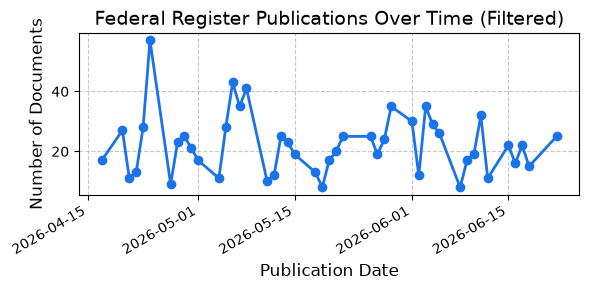

In [46]:
#Ensure publication_date is datetime for proper sorting
df_plot = df2.copy()
df_plot['publication_date'] = pd.to_datetime(df_plot['publication_date'])

#Group by date and count publications
daily_counts = df_plot.groupby('publication_date').size()

#Plotting
plt.figure(figsize=(6, 3))
daily_counts.plot(kind='line', marker='o', color='#1a73e8', linewidth=2)
plt.title('Federal Register Publications Over Time (Filtered)', fontsize=14)
plt.xlabel('Publication Date', fontsize=12)
plt.ylabel('Number of Documents', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

This acted as a good check, because it's where I realized I needed to implement pagination (see TODOs)

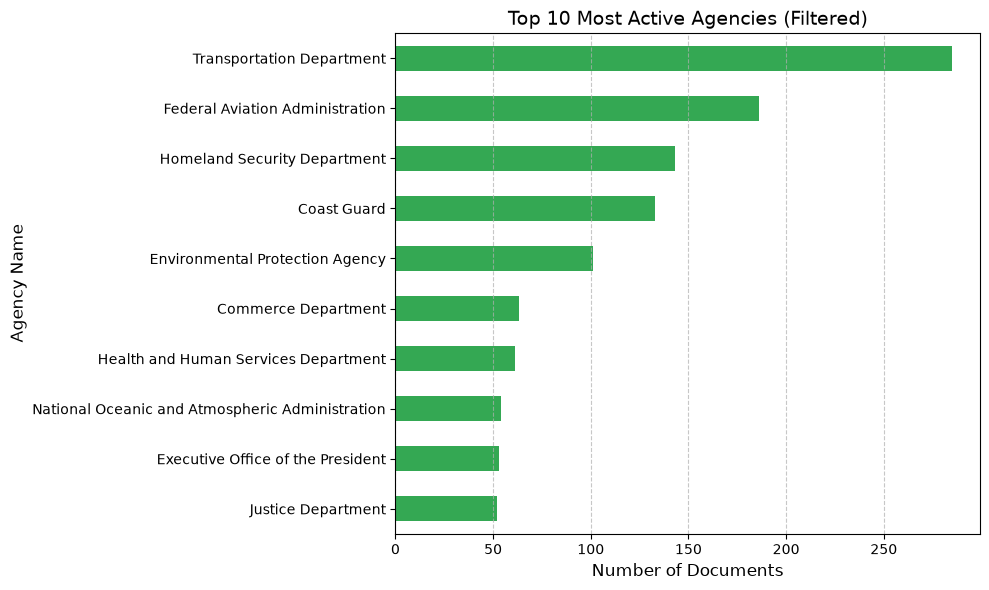

In [47]:
#Explode the agency_names list to count individual agency occurrences
agency_counts = df2['agency_names'].explode().value_counts().head(10)

#Plotting
plt.figure(figsize=(10, 6))
agency_counts.plot(kind='barh', color='#34a853')
plt.title('Top 10 Most Active Agencies (Filtered)', fontsize=14)
plt.xlabel('Number of Documents', fontsize=12)
plt.ylabel('Agency Name', fontsize=12)
plt.gca().invert_yaxis()  #Put the highest count at the top
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

After that brief sidequest, let's pick up where we left off, fetching the full text of this docs. In the future I might add a vector db, which we'd likely need full text for.

In [48]:
#Let's see what a single document looks like
def fetch_full_text_doc(url):
  """
  Fetches singular FR doc, returns as xml, and parses Federal Register XML and concatenates text from all <FP> tags: FP indicates the actual text
  """
  response = requests.get(url)
  doc_xml =  response.text
  soup = BeautifulSoup(doc_xml, features='xml')
  fp_tags = soup.find_all('FP')
  print(fp_tags)
  # Extract text from each tag and join with spaces
  clean_text = " ".join([tag.get_text(strip=True) for tag in fp_tags])
  return clean_text

sample = fetch_full_text_doc('https://www.federalregister.gov/documents/full_text/xml/2026/06/18/2026-12435.xml')

sample

[<FP>During National Homeownership Month, my Administration recommits to making housing more affordable so that young Americans and hardworking families can raise children, build memories, and create a future in a home of their own.</FP>, <FP>For too long, reckless spending, burdensome regulations, and failed housing policies drove up home prices and mortgage rates while mass illegal immigration and large institutional investors strained the housing supply. The result was a housing affordability crisis brought on by the failed leadership of the previous administration. Now, under my leadership, my Administration is fixing the mess we inherited and restoring the American Dream of homeownership.</FP>, <FP>From the first day I returned to office, I proudly signed an Executive Order to deliver price relief to Americans crushed by the left-wing cost-of-living crisisâlaunching a bold new era of progress on supply, affordability, and opportunity for every hardworking family across our count

'During National Homeownership Month, my Administration recommits to making housing more affordable so that young Americans and hardworking families can raise children, build memories, and create a future in a home of their own. For too long, reckless spending, burdensome regulations, and failed housing policies drove up home prices and mortgage rates while mass illegal immigration and large institutional investors strained the housing supply. The result was a housing affordability crisis brought on by the failed leadership of the previous administration. Now, under my leadership, my Administration is fixing the mess we inherited and restoring the American Dream of homeownership. From the first day I returned to office, I proudly signed an Executive Order to deliver price relief to Americans crushed by the left-wing cost-of-living crisisâ\x80\x94launching a bold new era of progress on supply, affordability, and opportunity for every hardworking family across our country. My Administrat

It works - let's have it go through the whole dataframe.
- **NOTE**: Although normally using .map() would be quicker, in this case we're just going to make a loop to avoid any throttling risk.

In [ ]:
# We will use a list to store the results then add to the dataframe
full_texts = []

print(f"Starting batch retrieval for {len(df2)} documents...")

# Loop over the filtered dataframe
for index, row in tqdm(df2.iterrows(), total=df2.shape[0]):
    url = row['full_text_xml_url']
    if pd.isna(url):
        full_texts.append("")
        continue

    try:
        # Using the helper function defined in the previous cell
        text = fetch_full_text_doc(url)
        full_texts.append(text)
    except Exception as e:
        print(f"Error fetching index {index}: {e}")
        full_texts.append("")

    # Sleep for 3 seconds to avoid throttling
    time.sleep(0.5)

# Assign the results to a new column
df2['full_text'] = full_texts

df2[['title', 'full_text']].head()

Perfect! We have our data, and can get some initial POC results. Lets do some final prep for input

In [56]:
df2["retrieval_text"] = (
    "Title: " + df2["title"].fillna("") +
    "\nAgency: " + df2["agency_names"].fillna("").astype(str) +
    "\nSummary: " + df2["excerpts"].fillna("") +
    "\nKeywords: " + df2["topics"].fillna("").astype(str)
)

Here are some example industry descriptions we can use to generate embeddings 

In [51]:
industry_profile_semis = """
Semiconductor manufacturing, chip fabrication,
advanced packaging, wafer processing,
photolithography, foundries, integrated circuits,
microelectronics supply chain, semiconductor workforce
"""

industry_profile_biotech = """This cluster encompasses federal oversight of healthcare delivery, medical innovation, biomedical research, and reimbursement systems. Regulatory activity spans medical device approvals, pharmaceutical oversight, clinical research governance, Medicare and Medicaid payment structures, health information management, and public-health reporting requirements. The sector sits at the intersection of patient safety, scientific advancement, and healthcare economics, making it one of the most consistently active areas of federal rulemaking. Changes in this domain can affect hospitals, insurers, biotechnology firms, medical-device manufacturers, pharmaceutical companies, research institutions, and healthcare technology vendors."""

industry_profile_cybersecurity = """Cybersecurity regulation increasingly functions as a cross-sector governance framework rather than a standalone technology issue. Federal actions in this space address cyber risk management, incident reporting, software security, supply-chain resilience, operational technology protection, and security standards for critical infrastructure operators. The sector reflects growing concerns that cyber incidents can disrupt essential services such as energy, healthcare, transportation, telecommunications, and financial systems. As a result, cybersecurity requirements are becoming embedded into broader compliance and enterprise-risk management programs across the economy."""

industry_profile_energy = """This theme encompasses the production, transmission, regulation, and security of energy resources and supporting infrastructure. Federal activity frequently addresses power generation, grid reliability, nuclear licensing, infrastructure modernization, operational safety, and resilience planning. Many regulatory initiatives are driven by concerns over energy security, reliability, technological modernization, and long-term capacity needs. Stakeholders include utilities, independent power producers, infrastructure developers, engineering firms, nuclear operators, and large industrial energy consumers."""

industry_profile_maritime_transport = """Transportation-related rulemaking focuses on the safe, efficient, and reliable movement of people and goods. Federal actions can involve vehicle safety standards, maritime operations, logistics systems, transportation infrastructure, regulatory compliance requirements, and operational risk management. The sector plays a foundational role in economic activity because transportation networks connect supply chains, labor markets, and consumer demand. Regulatory changes often seek to improve safety, efficiency, resilience, and interoperability across transportation modes."""

Now lets eval a given industry description against our prepared input col. We'll use dot product for semantic similarity.
- I'm using BAAI/bge-large to opt for retrieval quality over speed, given that in practice this tool shouldn't need to run incredibly often, and it is still reasonably quick.

In [57]:
model = SentenceTransformer('BAAI/bge-large-en-v1.5')

query = industry_profile_energy

query_emb = model.encode([f"Represent this industry description for retrieving relevant federal regulations: {query}"])

doc_embs = model.encode(
    df2["retrieval_text"].fillna("").tolist(),
    normalize_embeddings = True,
    show_progress_bar=True
)

scores = query_emb @ doc_embs.T
scores = scores[0]

df2["similarity"] = scores

results = df2.sort_values("similarity", ascending=False)

# Display the top matches
results[["title", "agency_names", "similarity"]].head(10)

Batches: 100%|██████████| 32/32 [15:11<00:00, 28.48s/it]


,title,agency_names,similarity
754,Licensing Requirements for Microreactors and O...,[Nuclear Regulatory Commission],0.685034
505,Licensing Requirements for Microreactors and O...,[Nuclear Regulatory Commission],0.682069
975,Repeal of Fossil Fuel Restrictions for New Fed...,[Energy Department],0.674356
907,Presidential Determination Pursuant to Section...,[Executive Office of the President],0.660093
9,Application for Authorization To Transmit Elec...,[Energy Department],0.660069
501,Modernizing NRC Regulations for Byproduct Mate...,[Nuclear Regulatory Commission],0.658469
423,Integrating Financial Technology Innovation In...,[Executive Office of the President],0.657570
368,Standards for Business Practices of Interstate...,"[Energy Department, Federal Energy Regulatory ...",0.654170
91,Energy Conservation Program: Energy Conservati...,[Energy Department],0.653042
68,Fee Schedules; Fee Recovery for Fiscal Year 2026,[Nuclear Regulatory Commission],0.653010


We can observe in this output that the first two columns might be duplicates. However, having inspected this further, it's more of an update to an initial reg under the same title. We might want to consider fixing this later, or flagging it as related in some way.

In [58]:
results.head()

,abstract,action,agencies,agency_names,cfr_topics,citation,comments_close_on,dates,document_number,effective_on,end_page,excerpts,executive_order_number,full_text_xml_url,presidential_document_number,proclamation_number,public_inspection_pdf_url,publication_date,raw_text_url,significant,signing_date,start_page,subtype,title,toc_doc,toc_subject,topics,type,volume,president.identifier,president.name,full_text,similarity,retrieval_text
754,The U.S. Nuclear Regulatory Commission (NRC) i...,Proposed rule; guidance; and request for comment.,"[{'raw_name': 'NUCLEAR REGULATORY COMMISSION',...",[Nuclear Regulatory Commission],"[{'cfr_part': '1', 'topics': ['Flags', 'Organi...",91 FR 23628,2026-06-15,Comments must be submitted electronically usin...,2026-08550,NaN,23766,The U.S. Nuclear Regulatory Commission (NRC) i...,NaN,https://www.federalregister.gov/documents/full...,NaN,NaN,https://public-inspection.federalregister.gov/...,2026/05/01,https://www.federalregister.gov/documents/full...,None,NaN,23628,NaN,Licensing Requirements for Microreactors and O...,Licensing Requirements for Microreactors and O...,NaN,"[Accounting, Administrative practice and proce...",Proposed Rule,91,donald-trump,Donald Trump,I. Obtaining Information and Submitting Commen...,0.685034,Title: Licensing Requirements for Microreactor...
505,NaN,NaN,"[{'raw_name': 'NUCLEAR REGULATORY COMMISSION',...",[Nuclear Regulatory Commission],[],91 FR 27870,NaN,NaN,C1-2026-08550,NaN,27871,NaN,NaN,https://www.federalregister.gov/documents/full...,NaN,NaN,https://public-inspection.federalregister.gov/...,2026/05/15,https://www.federalregister.gov/documents/full...,None,NaN,27870,NaN,Licensing Requirements for Microreactors and O...,Licensing Requirements for Microreactors and O...,NaN,[],Proposed Rule,91,donald-trump,Donald Trump,"âª 1. On page 23707, in the second column, in...",0.682069,Title: Licensing Requirements for Microreactor...
975,The Department of Energy (DOE) is reviewing it...,Notification of stay.,"[{'raw_name': 'DEPARTMENT OF ENERGY', 'name': ...",[Energy Department],[],91 FR 20868,NaN,"As of April 20, 2026, the compliance date for ...",2026-07628,NaN,20869,The Department of Energy (DOE) is reviewing it...,NaN,https://www.federalregister.gov/documents/full...,NaN,NaN,https://public-inspection.federalregister.gov/...,2026/04/20,https://www.federalregister.gov/documents/full...,None,NaN,20868,NaN,Repeal of Fossil Fuel Restrictions for New Fed...,Repeal of Fossil Fuel Restrictions for New Fed...,NaN,[],Rule,91,donald-trump,Donald Trump,,0.674356,Title: Repeal of Fossil Fuel Restrictions for ...
907,NaN,NaN,[{'raw_name': 'EXECUTIVE OFFICE OF THE PRESIDE...,[Executive Office of the President],[],91 FR 21929,NaN,NaN,2026-08011,NaN,21930,NaN,NaN,https://www.federalregister.gov/documents/full...,2026-09,NaN,https://public-inspection.federalregister.gov/...,2026/04/23,https://www.federalregister.gov/documents/full...,None,2026-04-20,21929,Determination,Presidential Determination Pursuant to Section...,"Defense Production Act of 1950, as Amended; Pr...",NaN,[],Presidential Document,91,donald-trump,Donald Trump,"On January 20, 2025, I issued Executive Order ...",0.660093,Title: Presidential Determination Pursuant to ...
9,The Department of Energy (DOE or the Departmen...,Final rule.,"[{'raw_name': 'DEPARTMENT OF ENERGY', 'name': ...",[Energy Department],"[{'cfr_part': '205', 'topics': ['Administrativ...",91 FR 36970,NaN,The effective date of the final rule is July 2...,2026-12475,2026-07-22,36975,The Department of Energy (DOE or the Departmen...,NaN,https://www.federalregister.gov/documents/full...,NaN,NaN,NaN,2026/06/22,https://www.federalregister.gov/documents/full...,True,NaN,36970,NaN,Application for Authorization To Transmit Elec...,Application for Authorization to Transmit Elec...,NaN,"[Administrative practice and procedure, Electr...",Rule,91,donald-trump,Donald Trump,,0.660069,Title: Application for Authorization To Transm...


At this point, we've evaluated 6 month's work of documents for relevance to a sector we want to track.
- The final output could be sent to a dashboard for quantitative tracking, downloaded to excel, fed into an LLM for further dissemination, or even just be used as a reference document.
- This could be made further flexible by running daily, utilizing vector dbs, and perhaps a bit more cleaning between document updates